# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Kadek Intan Dheya Pratiwi]
- **Email:** [intandheya11@gmail.com]
- **ID Dicoding:** [CDCC014D6X1038]

## Menentukan Pertanyaan Bisnis



*   Bagaimana perbedaan pola penyewaan sepeda berdasarkan kategori waktu (pagi,siang,sore,malam) selama periode 2011-2012?
*   Seberapa besar pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda, dan kondisi cuaca mana yang paling optimal untuk operasional?
*   Bagaimana perbedaan jumlah penyewaan sepeda antara hari kerja dan hari libur dilihat dari rata-rata penggunaan per hari?
*   Bagaimana distribusi tingkat penggunaan sepeda (rendah,sedang,tinggi) dan apa implikasinya terhadap manajemen operasional?





## Import Semua Packages/Library yang Digunakan

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [106]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:


*  Dataset berhasil dimuat yang terdiri dari data harian dan data per jam. Dari tampilan awal, terlihat bahwa jumlah penyewaan sepeda (cnt) dipengaruhi oleh berbagai faktor seperti waktu, kondisi cuaca, dan jenis pengguna. Selain itu, jumlah pengguna registered terlihat lebih dominan dibandingkan casual, yang mengindikasikan bahwa layanan bike sharing lebih banyak digunakan oleh pelanggan tetap.




### Assessing Data

Struktur Data & Tipe Data

In [107]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

MIssing Value & Duplikasi

In [108]:
print("Missing value day:\n", day_df.isna().sum())
print("Missing value day:\n", hour_df.isna().sum())

print("Duplikasi day:", day_df.duplicated().sum())
print("Duplikasi day:", hour_df.duplicated().sum())

Missing value day:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Missing value day:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplikasi day: 0
Duplikasi day: 0


Statistik Deskriptif

In [109]:
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Nilai Unik

In [110]:
day_df.nunique()
hour_df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


**Insight** :
Berdasarkan proses assesing data. dapat disimpulkan bahwa kualitas dataset tergolong baik karena tidak ditemukan missing value maupun data duplikat pada kedua dataset.
Namun, terdapat beberapa hal yang perlu diperhatikan sebelum analisis lebih lanjut :


1.   Kolom 'dteday' masih bertope object dan perlu dikonversi menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.
2.   Beberapa variabel seperti 'season'. 'weatherlist','workingday', dan 'holiday' memiliki jumlah nilai unik yang terbatas, sehingga lebih tepat diperlakukan sebagai data kategorikal.
3.  Hasil statistik deskriptif menunjukkan adanya variasi yang cukup besar pada jumlah penyewaan sepeda (cnt), yang mengindikasikan fluktuasi permintaan yang signifikan sepanjang waktu.
4.  Perbedaan antara jumlah pengguna casual dan registered cukup tinggi, yang menunjukkan adanya perbedaan perilaku penggunaan layanan.




### Cleaning Data

In [111]:
# copy dataset
df_day=day_df.copy()
df_hour = hour_df.copy ()

In [112]:
#Mengubah tipe data & Kategorikal

#Convert datetime
df_day['dtday'] = pd.to_datetime(df_day['dteday'])
df_hour['dtday'] = pd.to_datetime(df_hour['dteday'])

#Mapping kategori
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Mist', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'}

df_day['season'] = df_day['season'].map(season_map)
df_hour['season'] = df_hour['season'].map(season_map)

df_day['weathersit'] = df_day['weathersit'].map(weather_map)
df_hour['weathersit'] = df_hour['weathersit'].map(weather_map)

df_day['workingday'] = df_day['workingday'].map({0:'No', 1:'Yes'})
df_hour['workingday'] = df_hour['workingday'].map({0:'No', 1:'Yes'})



In [113]:
# Membuat kategori waktu berdasarkan jam
def categorize_time(hour):
    if 5 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 19:
        return 'Evening'
    else:
        return 'Night'

df_hour['time_category'] = df_hour['hr'].apply(categorize_time)

**Insight Cleaning: **

Data telah dibersihkan dengan mengubah tipe data tanggal menjadi datetime serta mengonversi variabel numerik menjadi kategorikal agar lebih mudah dianalisis.

Selain itu, dibuat variable baru yaitu kategori waktu (pago,siang,sore,malam) untuk mengetahui pola perilaku pengguna secara lebih spesifik berdasarkan waktu dalam sehari.



## Exploratory Data Analysis (EDA)

**Fokus Explorasi:**


*   Pola penyewaan berdasarkan kategori waktu
*   Pengaruh kondisi cuaca

*   Perbandingan hari kerja vs hari libur
*   Distribusi tingkat penggunaan






Pola berdasarkan kategori waktu

In [114]:
df_hour.groupby('time_category')['cnt'].mean().sort_values(ascending=False)

,cnt
time_category,
Evening,362.539938
Afternoon,239.033642
Morning,177.071264
Night,106.762745


**Insight:**
- Kategori Evening memiliki rata-rata penyewaan tinggi
- Morning juga cukup tinggi -> aktivitas berangkat kerja
- Night paling rendah -> aktivitas rendah
- Menunjukkan pola penggunaan berbasis rutinitas harian

Analisis pengaruh cuaca



In [115]:
df_hour.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

,cnt
weathersit,
Clear,204.869272
Mist,175.165493
Light Rain/Snow,111.579281
Heavy Rain/Snow,74.333333


**Insight:**
- Cuaca cerah menghasilkan penyewaan tertinggi
- Semakin buruk cuaca -> semakin turun penggunaan
- Cuaca menjadi faktor eksternal utama yang memengaruhi demand

**Analisis hari kerja vs hari libur **

In [116]:
df_day.groupby('workingday')['cnt'].mean()

,cnt
workingday,
No,4330.168831
Yes,4584.820000


**insight:**
- Rata-rata penyewaan lebih tinggi pada hari kerja
- Menunjukkan penggunaan dominan untuk aktivitas rutin
- Hari libur cenderung lebih rendah karena bukan kebutuhan utama

**Distribusi tingkat penggunaan**

In [117]:
df_day['usage_level']=pd.cut(
    df_day['cnt'],
    bins=[0,2000,4000,7000],
    labels=['Low','Medium','High']
)

df_day['usage_level'].value_counts()

,count
usage_level,
High,358
Medium,181
Low,98


**insight:**
- Mayoritas berada di kategori Medium dan High
- Permintaan relatif stabil
-  Sistem harus siap menangani volume tinggi

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola berdasarkan waktu

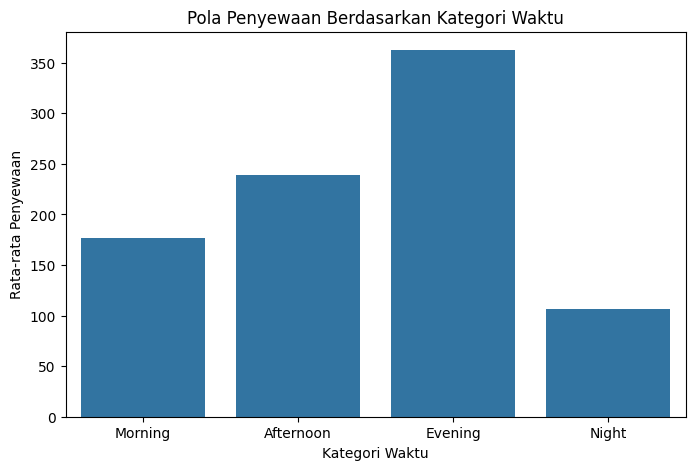

In [118]:
time_usage = df_hour.groupby('time_category')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=time_usage, x='time_category', y='cnt', order=['Morning','Afternoon', 'Evening','Night'])

plt.title('Pola Penyewaan Berdasarkan Kategori Waktu')
plt.xlabel('Kategori Waktu')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
- Peak terjadi di sore hari
- Ada pola "double peak" (pagi&sore)
- Menunjukkan pola commuting


### Pertanyaan 2: Pengaruh kondisi  cuaca

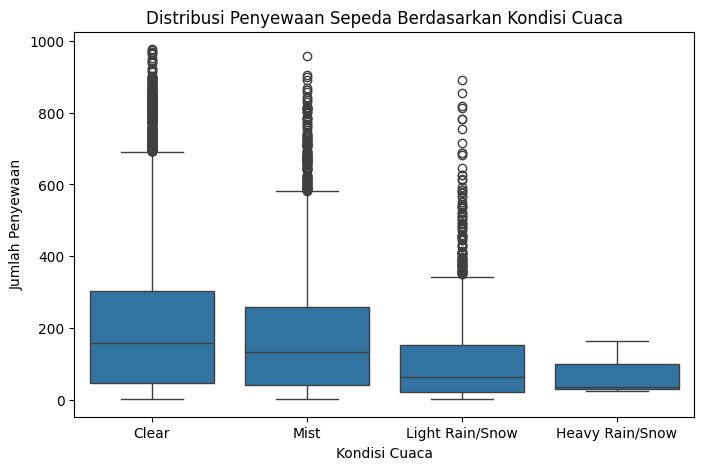

In [119]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_hour,
    x='weathersit',
    y='cnt'
)

plt.title('Distribusi Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Penyewaan')

plt.show()

**Insight:**
- Cuaca Clear memiliki median penyewaan paling tinggi
- Cuaca mist sedikit lebih rendah namun masih stabil
- Cuaca buruk (Light Rain/ Heavy Rain) menunjukkan:
    - Median rendah
    - Distribusi sempit

## Pertanyaan 3 : Hari Kerja vs Hari Libur


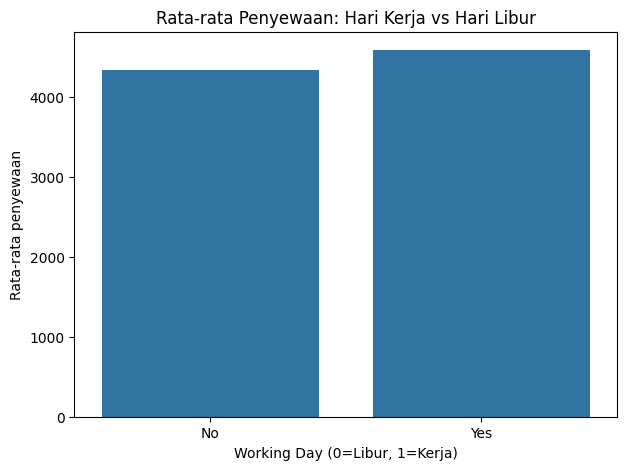

In [120]:
avg_usage = df_day.groupby('workingday')['cnt'].mean().reset_index()
avg_usage
svg_usage = df_day.groupby('workingday')['cnt'].mean().reset_index()
plt.figure(figsize=(7,5))

sns.barplot(
    data= avg_usage,
    x='workingday',
    y='cnt'
)

plt.title('Rata-rata Penyewaan: Hari Kerja vs Hari Libur')
plt.xlabel('Working Day (0=Libur, 1=Kerja)')
plt.ylabel('Rata-rata penyewaan')

plt.show()

**Insight:**
- Rata-rata penyewaan pada hari kerja lebih tinggi
- Hari libur menunjukkan penurunan

### Pertanyaan 4 : Distribusi Tingkat Penggunaan

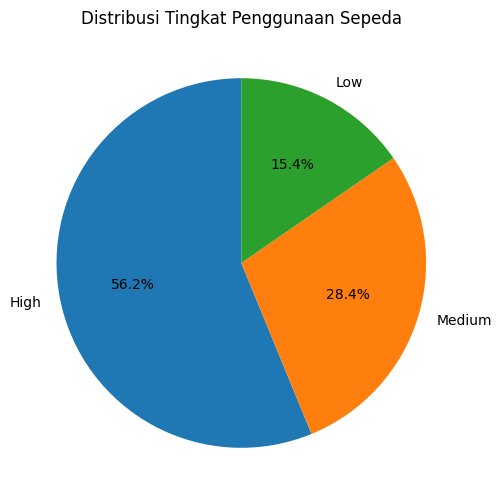

In [121]:
usage_dist = df_day['usage_level'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    usage_dist,
    labels=usage_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Tingkat Penggunaan Sepeda')
plt.show()

**insight:**
- Sebagian besar hari berada pada kategori medium dan high
- Kategori low relatif kecil
- Hal ini menunjukkan bahwa permintaan terhadap layanan bike sharing cenderung stabil pada tingkat menengah hingga tinggi, dengan fluktasi yang tidak terlalu ekstrem. Kondisi ini mencerminkan adanya pola penggunaan yang konsisten sepanjang periode pengamatan.

### Analisis Lanjutan : Clustering Berdasarkan Tingkat Penggunaan

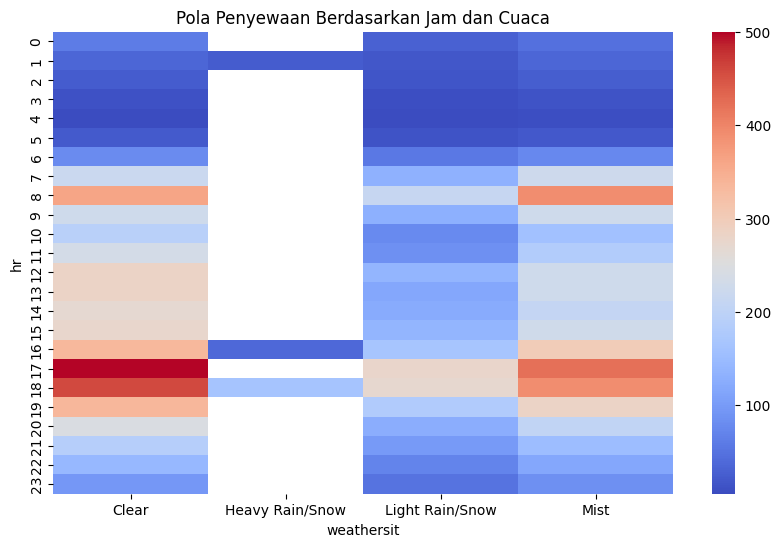

In [122]:
# Heatmap jam vs cuaca

pivot = df_hour.pivot_table(
    values='cnt',
    index='hr',
    columns='weathersit',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot,cmap='coolwarm')

plt.title('Pola Penyewaan Berdasarkan Jam dan Cuaca')
plt.show()

**insight:**
- Visualisasi heatmap menunjukkan bahwa pola penyewaan sepeda dipengaruhi oleh interaksi antara waktu dan kondisi cuaca. Pada cuaca cerah, terlihat bahwa mencapai puncaknya pada jam sibuk, terutama pagi dan sore hari. Namun, pada kondisi cuaca yang lebih buruk seperti hujan ringan hingga berat, terjadi penurunan jumlah penyewa pada hampir seluruh jam, termasuk pada periode puncak. Hal ini menunjukkan bahwa meskipun memiliki pola permintaan yang konsisten, kondisi cuaca dapat secara signifikan menkan tingkat penggunaan sepeda.

## Conclusion

### - Pertanyaan 1: Pola Penyewaan Berdasarkan Waktu

Penyewaan sepeda menunjukkan pola yang jelas berdasarkan kategori waktu, dengan puncak penggunaan terjadi pada pagi dan sore hari. Pola ini mengindikasikan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti berangkat dan pulang kerja.

### -Pertanyaan 2: Pengaruh kondisi cuaca

Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Cuaca cerah menghasilkan tingkat penyewaan tertinggi, sedangkan cuaca buruk seperti hujan menyebabkan penurunan yang cukup drastis. Hal ini menunjukkan bahwa cuaca merupakan faktor penting dalam menentukan tingkat permintaan.

### -Pertanyaan 3 : Perbedaan Hari Kerja dan Hari Libur

Rata-rata penyewaan sepeda lebih tinggi pada hari kerja dibandingkan hari libur. Hal ini menunjukkan bahwa penggunaan sepeda lebih didominasi oleh kebutuhan transportasi harian dibandingkan aktivitas rekreasi.

### -Pertanyaan 4 : Distribusi Tingkat Penggunaan

SEbagian besar hari berada pada kategori penggunaan menengah hingga tinggi, yang menunjukkan bahwa permintaan terhadap layanan bike sharing relatif stabil. Hal ini mengindikasikan perlunya pengelolaan operasional yang konsisten untuk menjaga ketersediaan layanan.

